# Cardiovascular Disease Risk Prediction

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("CVD_cleaned.csv.xls")
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poo,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


## 2. Check number of rows and columns

In [3]:
df.shape

(308854, 19)

**through this we can know about rows and columns in dataframe..**
**dataset containing 308854 rows and 19 columns**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  int64  
 12  Weight_(kg)                   308854 non-nul

In [5]:
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


In [6]:
df.describe(include=object)

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Smoking_History
count,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854
unique,7,5,2,2,2,2,2,4,2,5,13,2
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,No
freq,110395,239371,239381,283883,278860,278976,246953,259141,207783,160186,33434,183590


## 3. Missing Value Analysis

In [7]:
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [8]:
df.isnull().sum(axis=1)

0         0
1         0
2         0
3         0
4         0
         ..
308849    0
308850    0
308851    0
308852    0
308853    0
Length: 308854, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(80)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [13]:
for col in categorical_cols:
    print("\nDifferent values in ",col,":")
    print(df[col].unique())


Different values in  General_Health :
['Poo' 'Very Good' 'Poor' 'Good' 'Fair' 'Excellent' 'poo']

Different values in  Checkup :
['Within the past 2 years' 'Within the past year' '5 or more years ago'
 'Within the past 5 years' 'Never']

Different values in  Exercise :
['No' 'Yes']

Different values in  Heart_Disease :
['No' 'Yes']

Different values in  Skin_Cancer :
['No' 'Yes']

Different values in  Other_Cancer :
['No' 'Yes']

Different values in  Depression :
['No' 'Yes']

Different values in  Diabetes :
['No' 'Yes' 'No, pre-diabetes or borderline diabetes'
 'Yes, but female told only during pregnancy']

Different values in  Arthritis :
['Yes' 'No']

Different values in  Sex :
['Female' 'Male' 'F' 'M' 'm']

Different values in  Age_Category :
['70-74' '60-64' '75-79' '80+' '65-69' '50-54' '45-49' '18-24' '30-34'
 '55-59' '35-39' '40-44' '25-29']

Different values in  Smoking_History :
['Yes' 'No']


# 4. Exploratory Data Analysis (to showcase the relationships between variables, distributions, and patterns)

## Bar plot for Heart Disease distribution

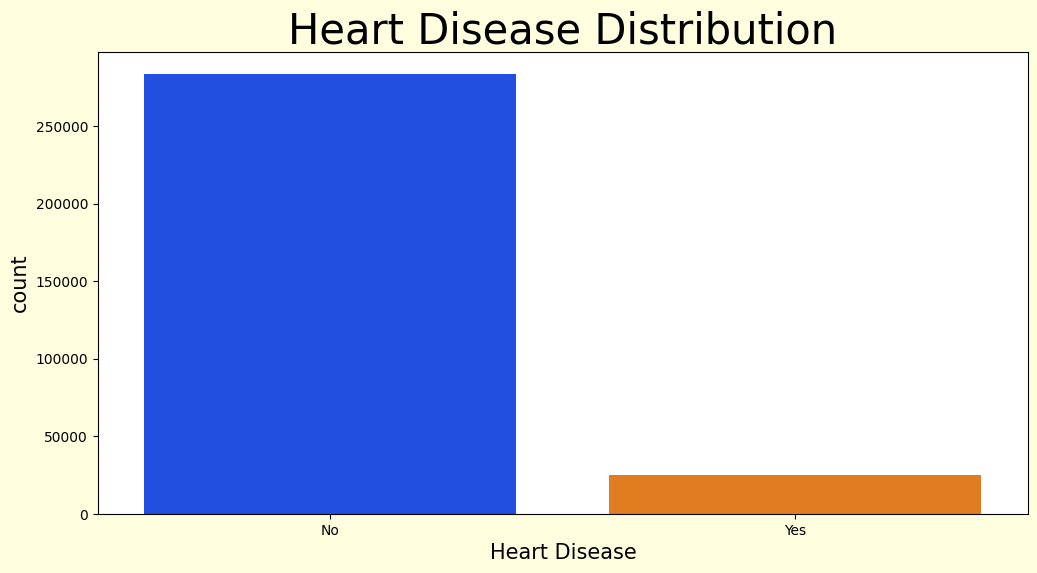

In [14]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
sns.countplot(data=df, x='Heart_Disease', hue="Heart_Disease",palette='bright')
plt.title('Heart Disease Distribution', fontsize=30)
plt.xlabel('Heart Disease', fontsize=15)
plt.ylabel('count', fontsize=15)
plt.show()

In [15]:
df['General_Health'] = df['General_Health'].replace({'poo': 'Poor'})
df['General_Health'] = df['General_Health'].replace({'Poo': 'Poor'})

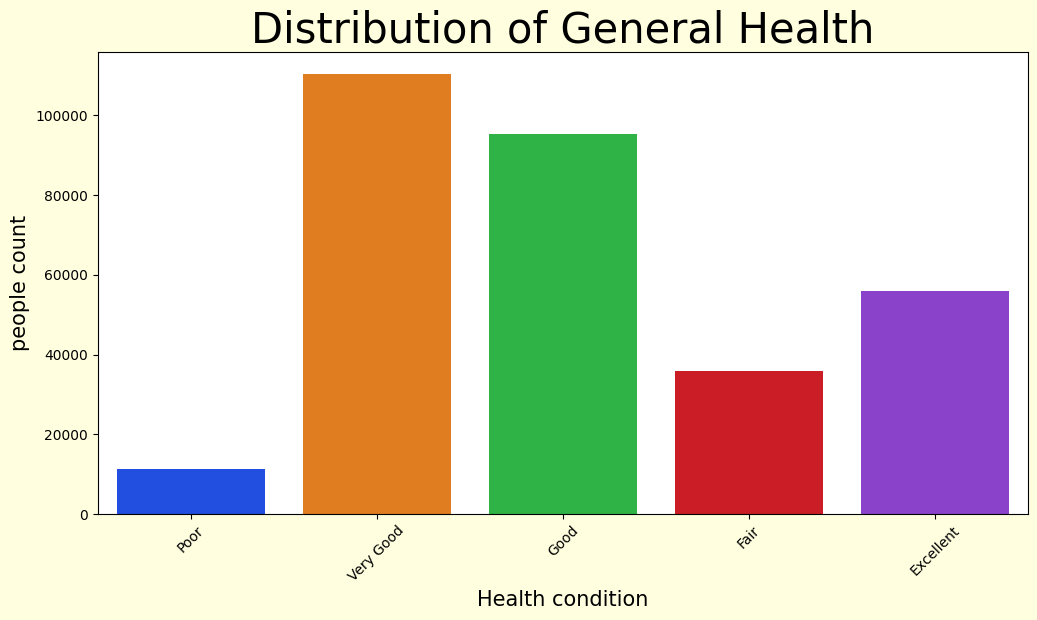

In [16]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
sns.countplot(data=df, x='General_Health', hue="General_Health",palette='bright')
plt.title('Distribution of General Health', fontsize=30)
plt.xlabel('Health condition', fontsize=15)
plt.ylabel('people count', fontsize=15)
plt.xticks(rotation=45)
plt.show()

In [17]:
df['Sex'] = df['Sex'].replace({'F': 'Female'})
df['Sex'] = df['Sex'].replace({'m': 'Male'})
df['Sex'] = df['Sex'].replace({'M': 'Male'})

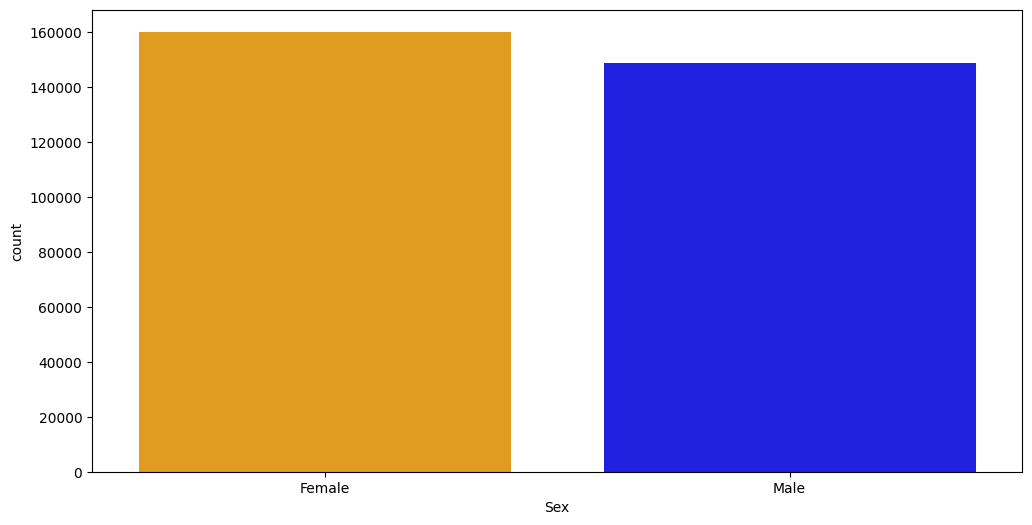

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='Sex',hue='Sex',palette=['orange','blue'])
plt.show()

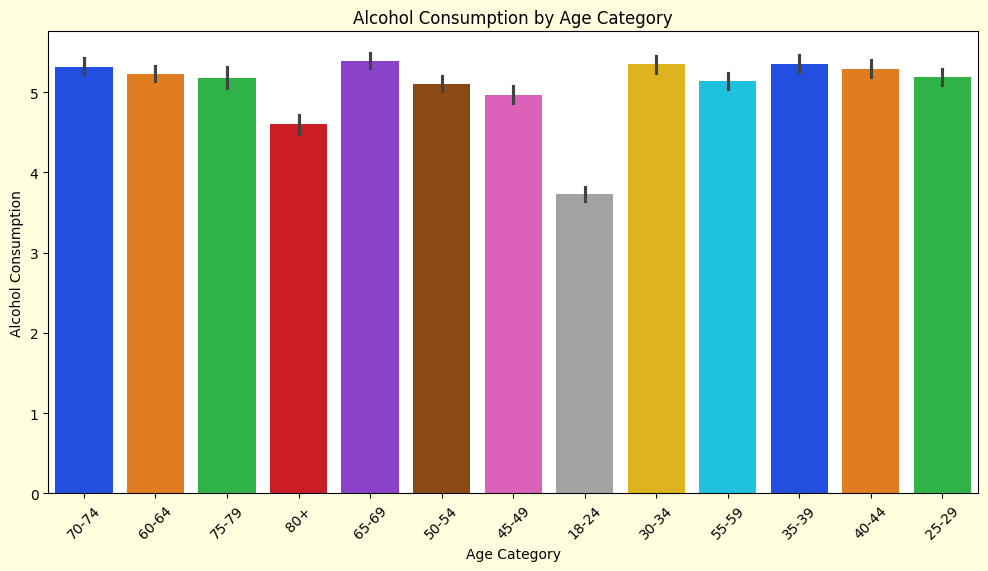

In [19]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
sns.barplot(data=df, x='Age_Category', y='Alcohol_Consumption', palette='bright')
plt.title('Alcohol Consumption by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Alcohol Consumption')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

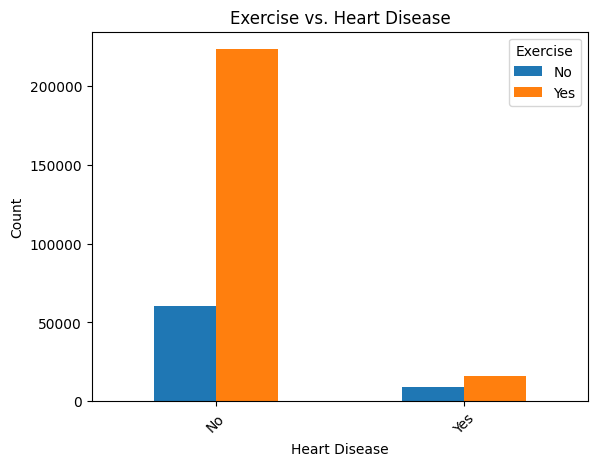

In [20]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
exercise_heart = pd.crosstab(df['Heart_Disease'], df['Exercise'])
exercise_heart.plot(kind='bar')
plt.title('Exercise vs. Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

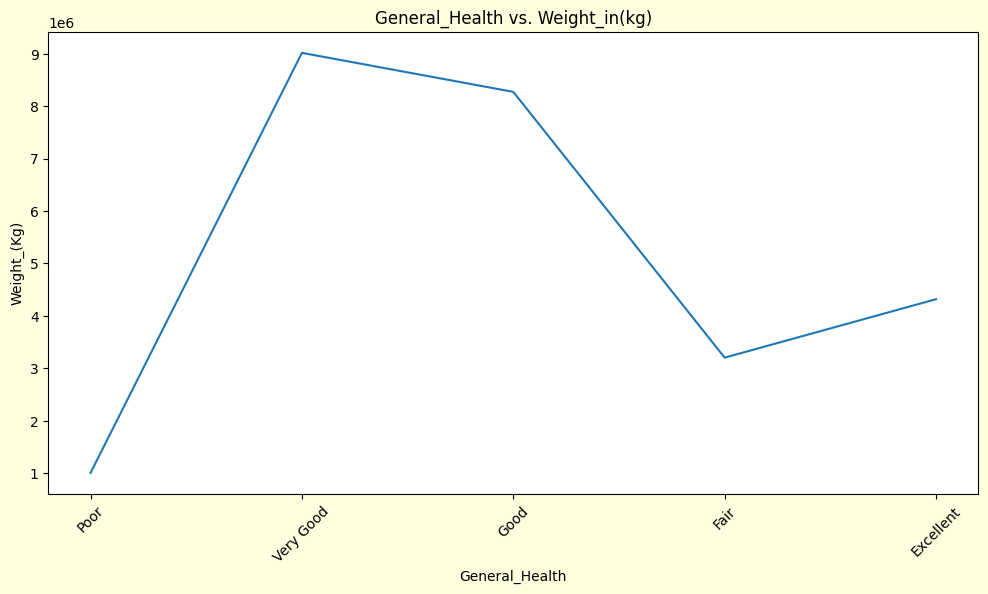

In [21]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
sns.lineplot(data=df, x='General_Health', y='Weight_(kg)', estimator='sum', ci=None)
plt.title('General_Health vs. Weight_in(kg)')
plt.xlabel('General_Health')
plt.ylabel('Weight_(Kg)')
plt.xticks(rotation=45)
plt.show()

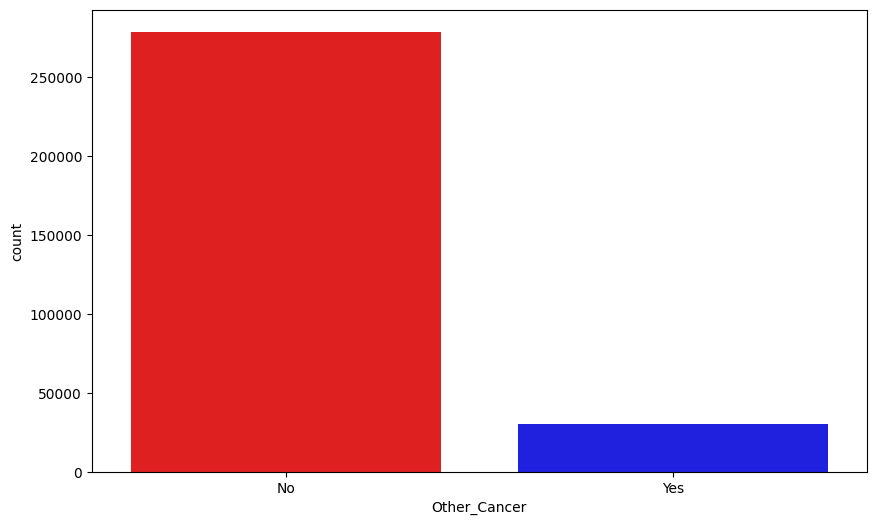

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Other_Cancer",hue="Other_Cancer",palette=['red','blue'])
plt.xlabel('Other_Cancer')
plt.show()

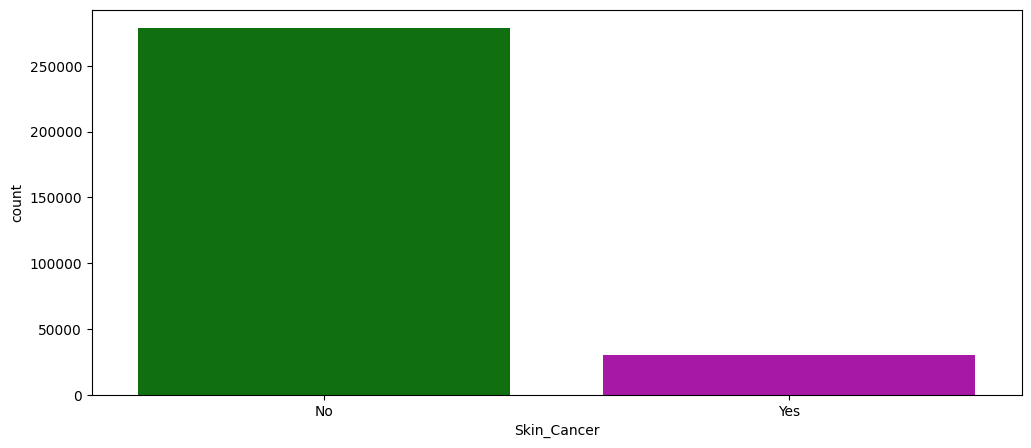

In [23]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='Skin_Cancer',palette=['g','m'])
plt.show()

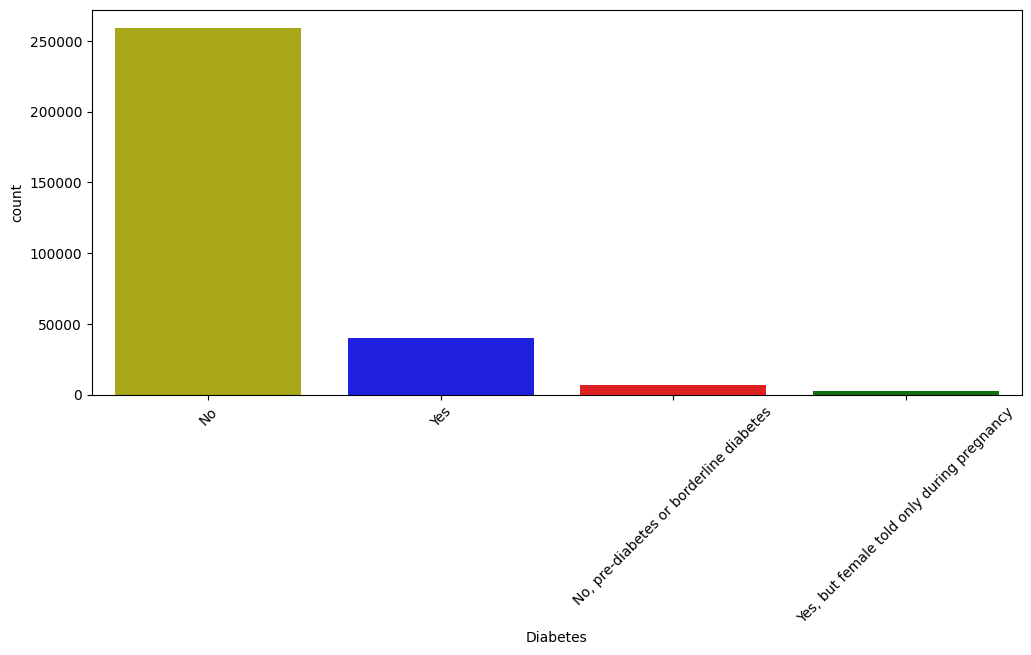

In [24]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='Diabetes',hue='Diabetes',palette=['y','b','r','g'])
plt.xticks(rotation=45)
plt.show()

## Box plot for BMI across different Age Categories

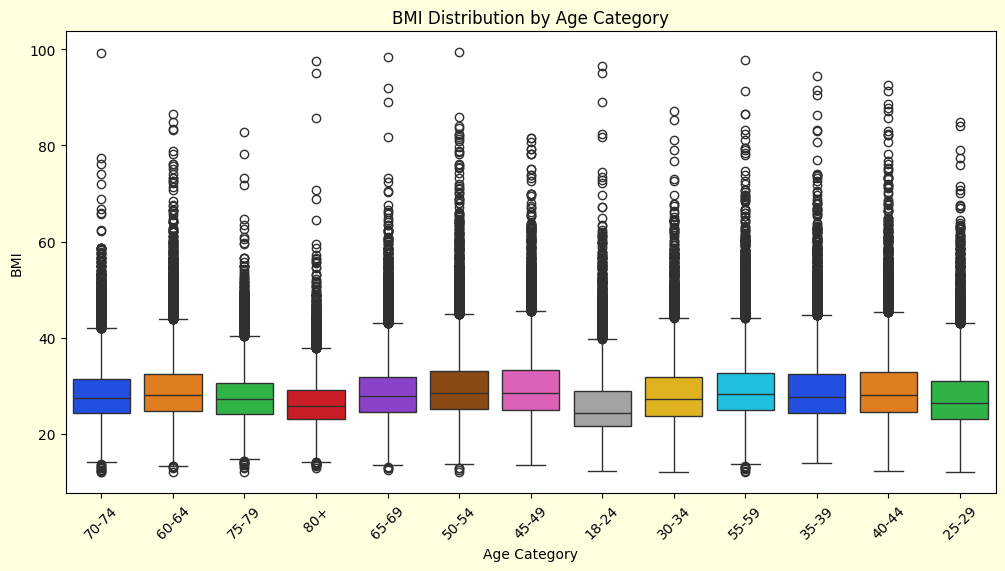

In [25]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
sns.boxplot(data=df, x='Age_Category', y='BMI', palette="bright")
plt.title('BMI Distribution by Age Category')
plt.xlabel('Age Category')
plt.ylabel('BMI')
plt.xticks(rotation=45)
plt.show()

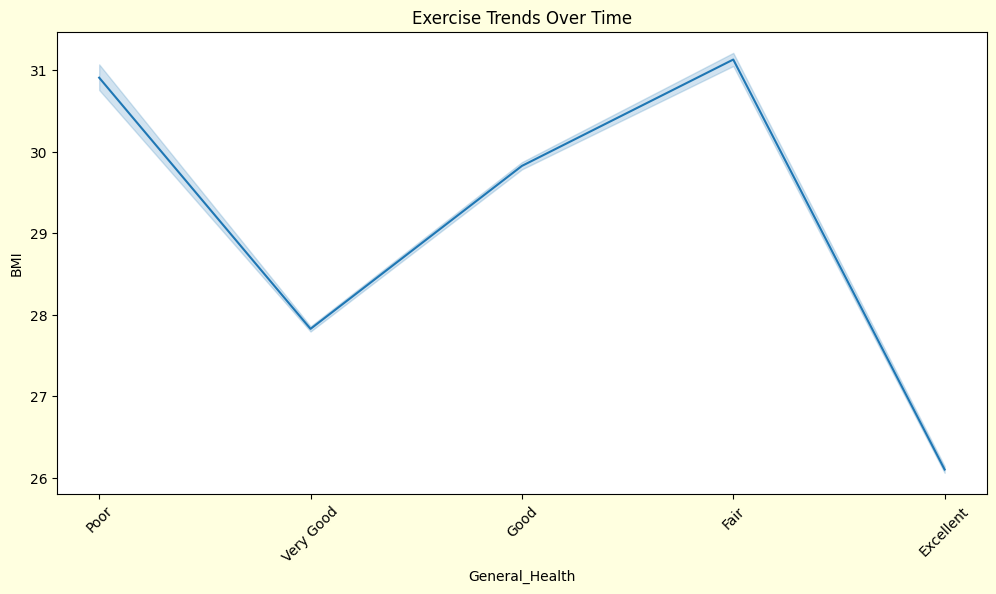

In [26]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
sns.lineplot(x='General_Health', y='BMI', data=df)
plt.title('Exercise Trends Over Time')
plt.xlabel('General_Health')
plt.ylabel('BMI')
plt.xticks(rotation=45)
plt.show()

## Pie chart for Smoking History distribution

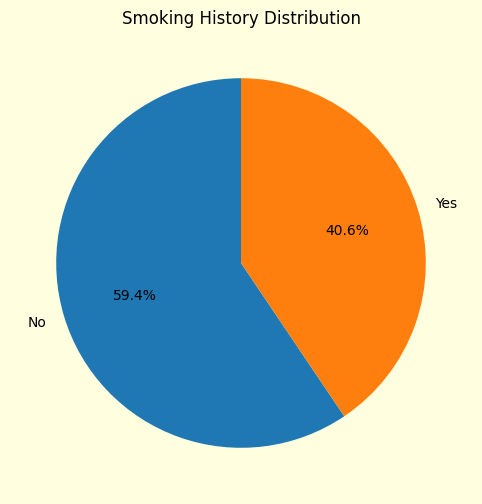

In [27]:
plt.figure(figsize=(12, 6),facecolor="lightyellow")
smoking_counts = df['Smoking_History'].value_counts()
smoking_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Smoking History Distribution')
plt.ylabel('')
plt.show()

# 5. Univariate Analysis

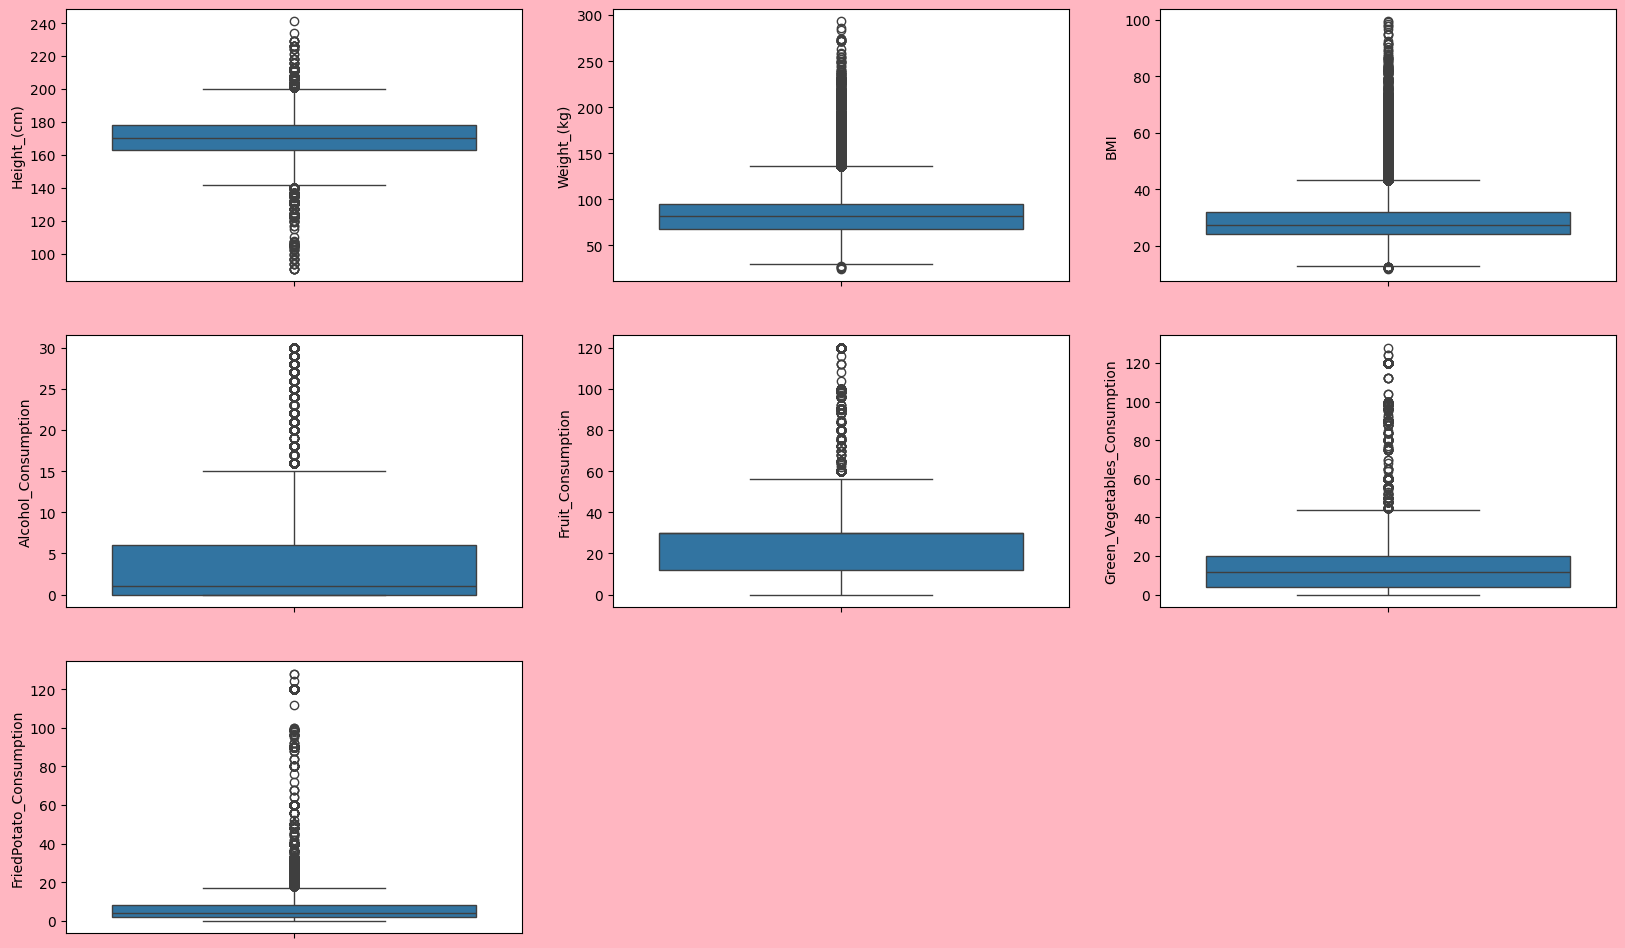

In [28]:
plt.figure(figsize=(20, 12),facecolor="lightpink")
for i, column in enumerate(df.select_dtypes(include='number'),1):
    plt.subplot(3,3,i)
    sns.boxplot(df[column])

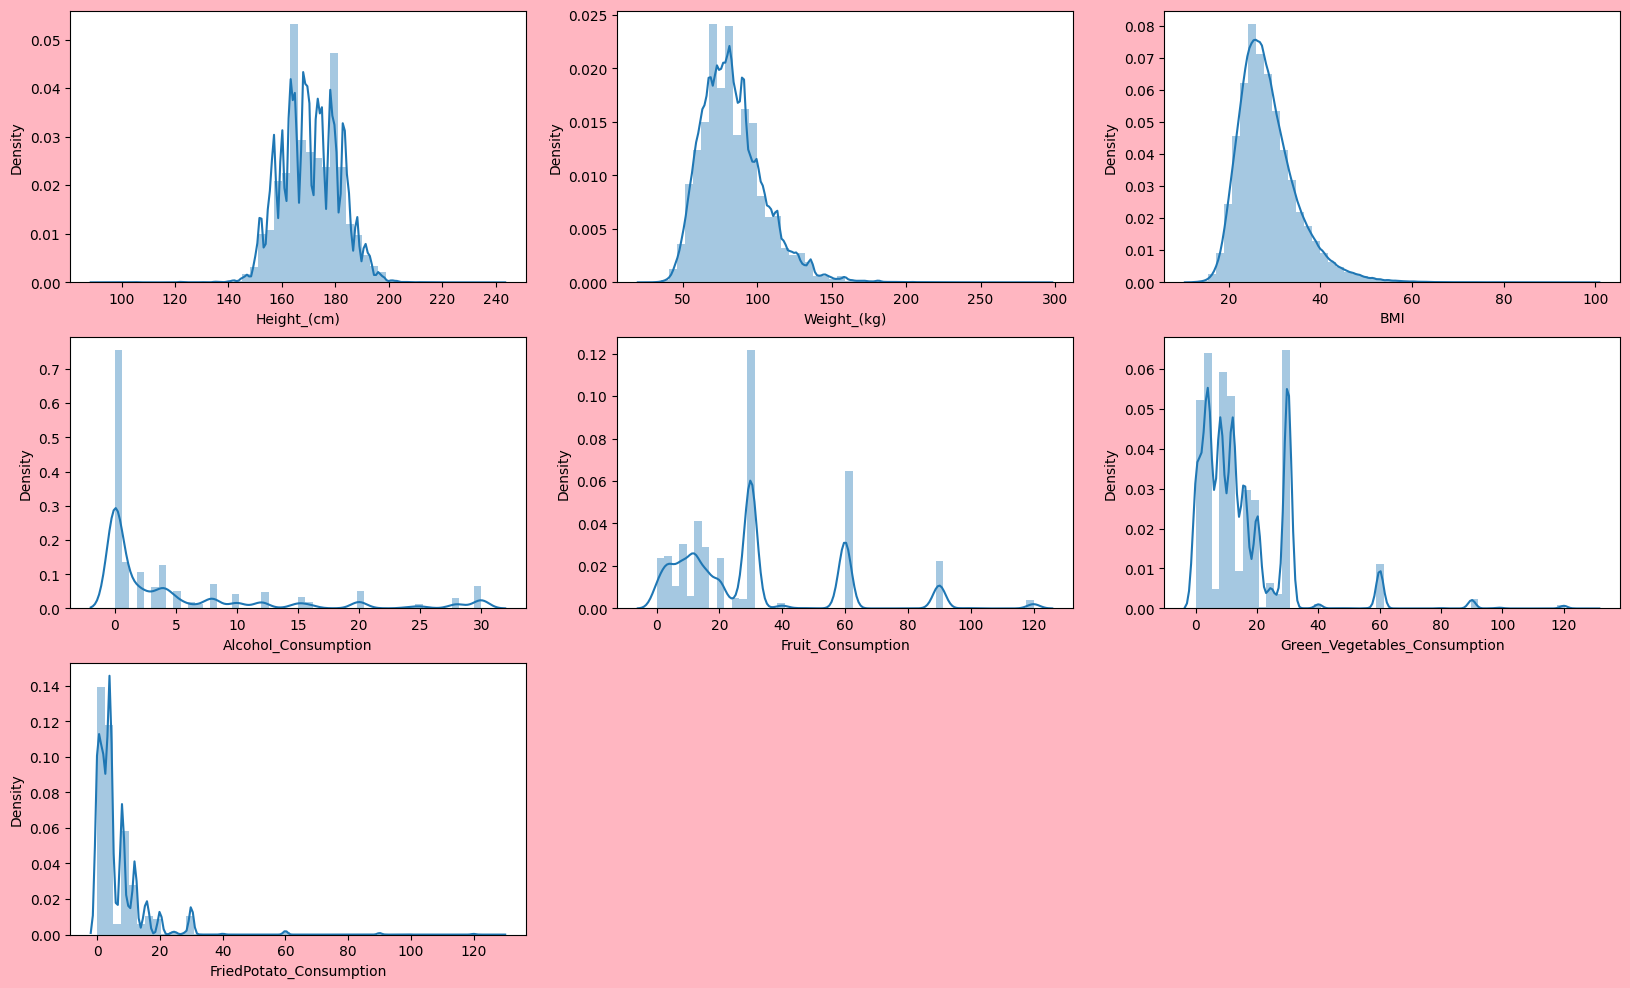

In [29]:
plt.figure(figsize=(20, 12),facecolor="lightpink")
for i, column in enumerate(df.select_dtypes(include='number'),1):
    plt.subplot(3,3,i)
    sns.distplot(df[column])

# skewness

In [30]:
for i in df.select_dtypes(include='number'):
    skewness=df[i].skew()
    print("The skewness of",i,"is",skewness)

The skewness of Height_(cm) is 0.015299417864624468
The skewness of Weight_(kg) is 1.0580988510087124
The skewness of BMI is 1.3764522532204038
The skewness of Alcohol_Consumption is 1.8852613372718061
The skewness of Fruit_Consumption is 1.2484473468538915
The skewness of Green_Vegetables_Consumption is 2.415919929560119
The skewness of FriedPotato_Consumption is 4.911907483499695


# Label Encoder

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
enc=LabelEncoder()

In [33]:
categorical_columns = ['General_Health', 'Smoking_History', 'Exercise','Depression', 'Diabetes', 'Arthritis', 'Heart_Disease','Skin_Cancer','Age_Category','Sex','Checkup','Other_Cancer']

In [34]:
for col in categorical_columns:
    df[col] = enc.fit_transform(df[col])

In [35]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3,2,0,0,0,0,0,0,1,0,10,150,32.66,14.54,1,0,30,16,12
1,4,4,0,1,0,0,0,2,0,0,10,165,77.11,28.29,0,0,30,0,4
2,4,4,1,0,0,0,0,2,0,0,8,163,88.45,33.47,0,4,12,3,16
3,3,4,1,1,0,0,0,2,0,1,11,180,93.44,28.73,0,0,30,30,8
4,2,4,0,0,0,0,0,0,0,1,12,191,88.45,24.37,1,0,8,4,0


# 6. Data Preprocessing

# Correlation and Heatmap

In [36]:
corr = df.corr()

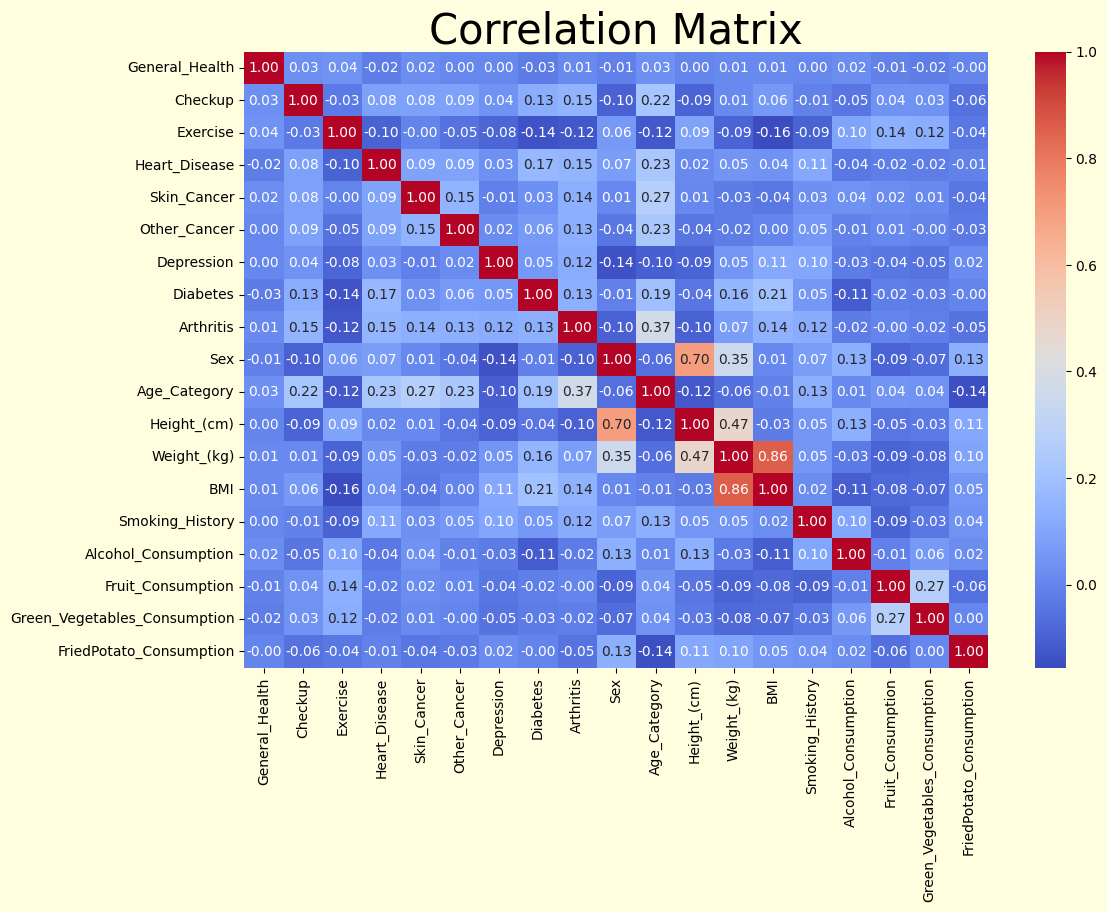

In [37]:
plt.figure(figsize=(12, 8),facecolor="lightyellow")
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix',fontsize=30)
plt.show()



# Checking for outliers(extreme  high or low values)

In [38]:
df.dtypes

General_Health                    int64
Checkup                           int64
Exercise                          int64
Heart_Disease                     int64
Skin_Cancer                       int64
Other_Cancer                      int64
Depression                        int64
Diabetes                          int64
Arthritis                         int64
Sex                               int64
Age_Category                      int64
Height_(cm)                       int64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                   int64
Alcohol_Consumption               int64
Fruit_Consumption                 int64
Green_Vegetables_Consumption      int64
FriedPotato_Consumption           int64
dtype: object

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.describe()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000,308774.000000
mean,2.273232,3.514975,0.775017,0.080871,0.097133,0.096760,0.200467,0.308232,0.327304,0.481320,6.536104,170.615220,83.590399,28.626813,0.405662,5.097557,29.834290,15.109517,6.297237
std,1.494016,1.019649,0.417572,0.272638,0.296139,0.295631,0.400350,0.724454,0.469230,0.499652,3.523495,10.658452,21.344664,6.522810,0.491021,8.200434,24.877812,14.926912,8.583837
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,163.000000,68.040000,24.210000,0.000000,0.000000,12.000000,4.000000,2.000000
50%,2.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,170.000000,81.650000,27.440000,0.000000,1.000000,30.000000,12.000000,4.000000
75%,4.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,9.000000,178.000000,95.250000,31.850000,1.000000,6.000000,30.000000,20.000000,8.000000
max,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,12.000000,241.000000,293.020000,99.330000,1.000000,30.000000,120.000000,128.000000,128.000000


# Treatment of outliers

In [41]:
df.rename(columns={"Height_(cm)":"Height","Weight_(kg)":"Weight"},inplace=True)
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height,Weight,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3,2,0,0,0,0,0,0,1,0,10,150,32.66,14.54,1,0,30,16,12
1,4,4,0,1,0,0,0,2,0,0,10,165,77.11,28.29,0,0,30,0,4
2,4,4,1,0,0,0,0,2,0,0,8,163,88.45,33.47,0,4,12,3,16
3,3,4,1,1,0,0,0,2,0,1,11,180,93.44,28.73,0,0,30,30,8
4,2,4,0,0,0,0,0,0,0,1,12,191,88.45,24.37,1,0,8,4,0


In [42]:
q1= df.quantile(0.25)
q1

General_Health                    1.00
Checkup                           4.00
Exercise                          1.00
Heart_Disease                     0.00
Skin_Cancer                       0.00
Other_Cancer                      0.00
Depression                        0.00
Diabetes                          0.00
Arthritis                         0.00
Sex                               0.00
Age_Category                      4.00
Height                          163.00
Weight                           68.04
BMI                              24.21
Smoking_History                   0.00
Alcohol_Consumption               0.00
Fruit_Consumption                12.00
Green_Vegetables_Consumption      4.00
FriedPotato_Consumption           2.00
Name: 0.25, dtype: float64

In [43]:
q3= df.quantile(0.75)
q3

General_Health                    4.00
Checkup                           4.00
Exercise                          1.00
Heart_Disease                     0.00
Skin_Cancer                       0.00
Other_Cancer                      0.00
Depression                        0.00
Diabetes                          0.00
Arthritis                         1.00
Sex                               1.00
Age_Category                      9.00
Height                          178.00
Weight                           95.25
BMI                              31.85
Smoking_History                   1.00
Alcohol_Consumption               6.00
Fruit_Consumption                30.00
Green_Vegetables_Consumption     20.00
FriedPotato_Consumption           8.00
Name: 0.75, dtype: float64

In [44]:
IQR = q3-q1
IQR

General_Health                   3.00
Checkup                          0.00
Exercise                         0.00
Heart_Disease                    0.00
Skin_Cancer                      0.00
Other_Cancer                     0.00
Depression                       0.00
Diabetes                         0.00
Arthritis                        1.00
Sex                              1.00
Age_Category                     5.00
Height                          15.00
Weight                          27.21
BMI                              7.64
Smoking_History                  1.00
Alcohol_Consumption              6.00
Fruit_Consumption               18.00
Green_Vegetables_Consumption    16.00
FriedPotato_Consumption          6.00
dtype: float64

In [45]:
high_out_Height=q3.Height+1.5*IQR.Height
high_out_Height

np.float64(200.5)

In [46]:
low_out_Height=q1.Height-1.5*IQR.Height
low_out_Height

np.float64(140.5)

In [47]:
high_out_Weight=q3.Weight+1.5*IQR.Weight
high_out_Weight

np.float64(136.065)

In [48]:
low_out_Weight=q1.Weight-1.5*IQR.Weight
low_out_Weight

np.float64(27.225000000000016)

In [49]:
high_out_BMI=q3.BMI+1.5*IQR.BMI
high_out_BMI

np.float64(43.31)

In [50]:
low_out_BMI=q1.BMI-1.5*IQR.BMI
low_out_BMI

np.float64(12.75)

In [51]:
high_out_Alcohol=q3.Alcohol_Consumption+1.5*IQR.Alcohol_Consumption
high_out_Alcohol

np.float64(15.0)

In [52]:
low_out_Alcohol=q1.Alcohol_Consumption-1.5*IQR.Alcohol_Consumption
low_out_Alcohol

np.float64(-9.0)

In [53]:
high_out_Fruit=q3.Fruit_Consumption+1.5*IQR.Fruit_Consumption
high_out_Fruit

np.float64(57.0)

In [54]:
low_out_Fruit=q1.Fruit_Consumption-1.5*IQR.Fruit_Consumption
low_out_Fruit

np.float64(-15.0)

In [55]:
high_out_Green=q3.Green_Vegetables_Consumption+1.5*IQR.Green_Vegetables_Consumption
high_out_Green

np.float64(44.0)

In [56]:
low_out_Green=q1.Green_Vegetables_Consumption-1.5*IQR.Green_Vegetables_Consumption
low_out_Green

np.float64(-20.0)

In [57]:
high_out_Fried=q3.FriedPotato_Consumption+1.5*IQR.FriedPotato_Consumption
high_out_Fried

np.float64(17.0)

In [58]:
low_out_Fried=q1.FriedPotato_Consumption-1.5*IQR.FriedPotato_Consumption
low_out_Fried

np.float64(-7.0)

## Capping

In [59]:
new_df = df.copy()
new_df['Height']=np.where(new_df['Height']>high_out_Height,
                    high_out_Height,
                    np.where(new_df['Height']<low_out_Height,
                    low_out_Height,
                    new_df['Height']
    )
)

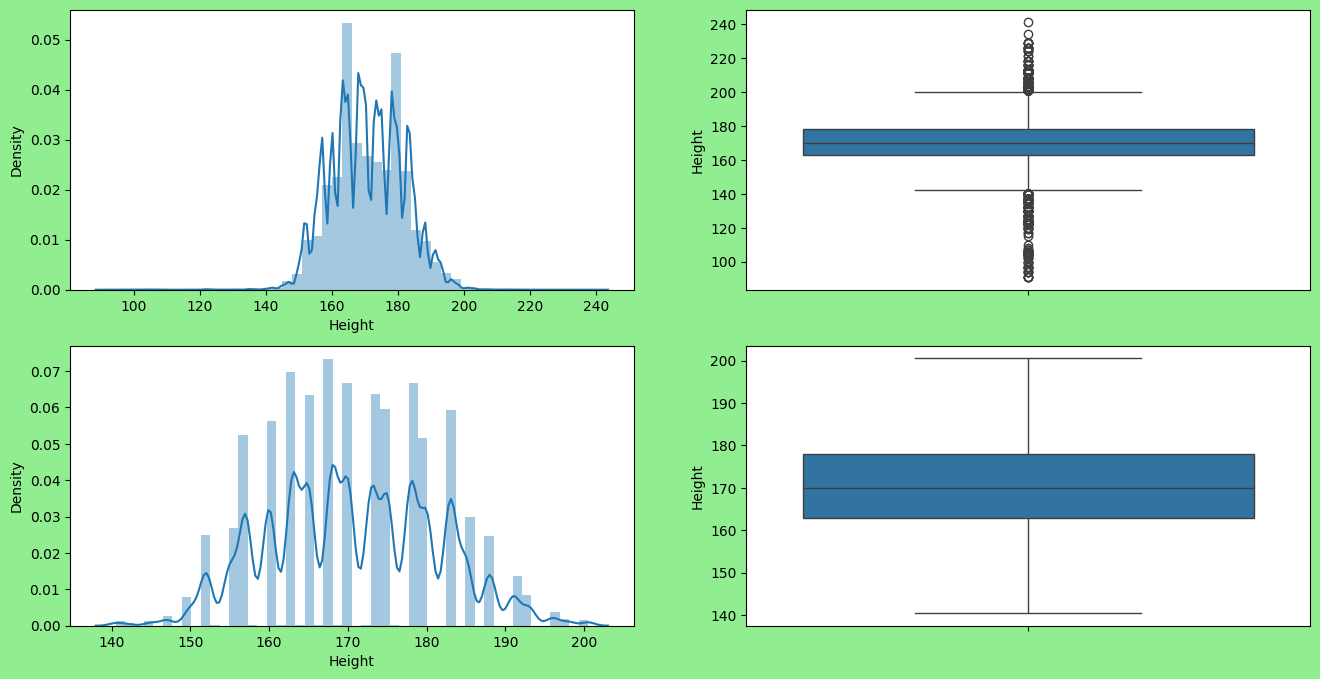

In [60]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['Height'])

plt.subplot(2,2,2)
sns.boxplot(df['Height'])

plt.subplot(2,2,3)
sns.distplot(new_df['Height'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Height'])

plt.show()

In [61]:
new_df['Weight']=np.where(new_df['Weight']>high_out_Weight,
                    high_out_Weight,
                    np.where(new_df['Weight']<low_out_Weight,
                    low_out_Weight,
                    new_df['Weight']
    )
)

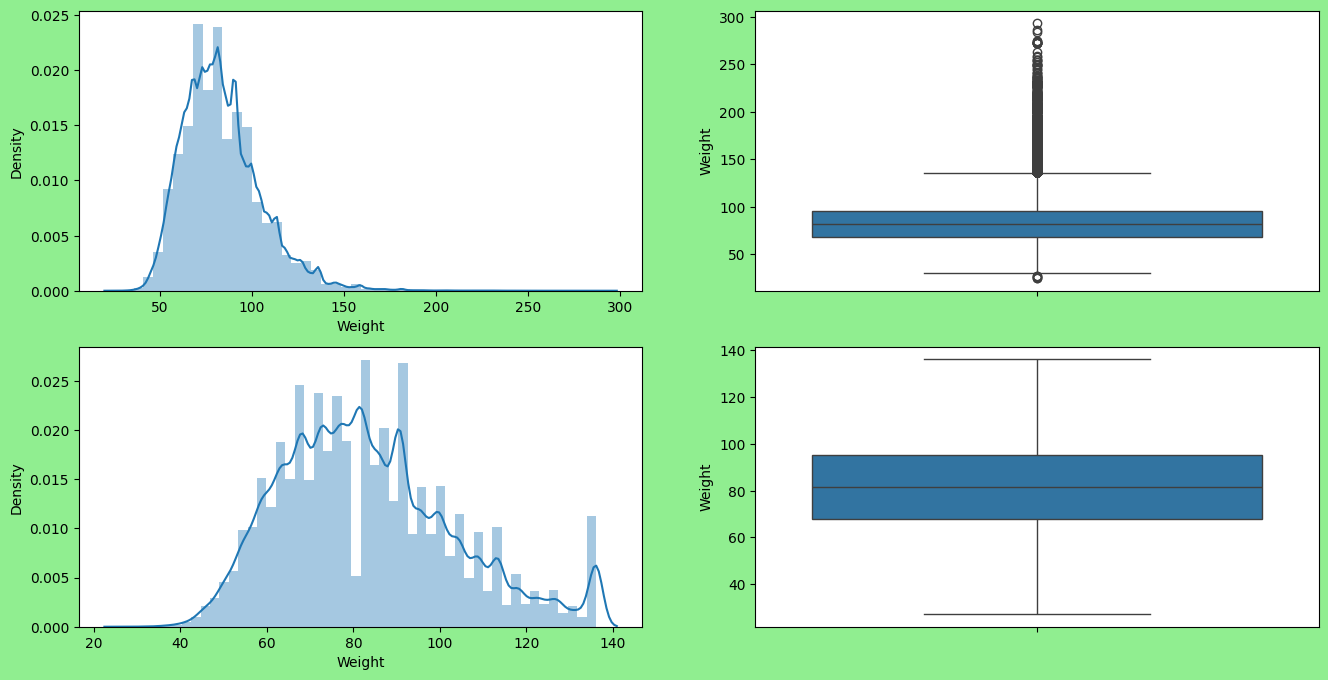

In [62]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['Weight'])

plt.subplot(2,2,2)
sns.boxplot(df['Weight'])

plt.subplot(2,2,3)
sns.distplot(new_df['Weight'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Weight'])

plt.show()

In [63]:
new_df['BMI']=np.where(new_df['BMI']>high_out_BMI,
                    high_out_BMI,
                    np.where(new_df['BMI']<low_out_BMI,
                    low_out_BMI,
                    new_df['BMI']
    )
)

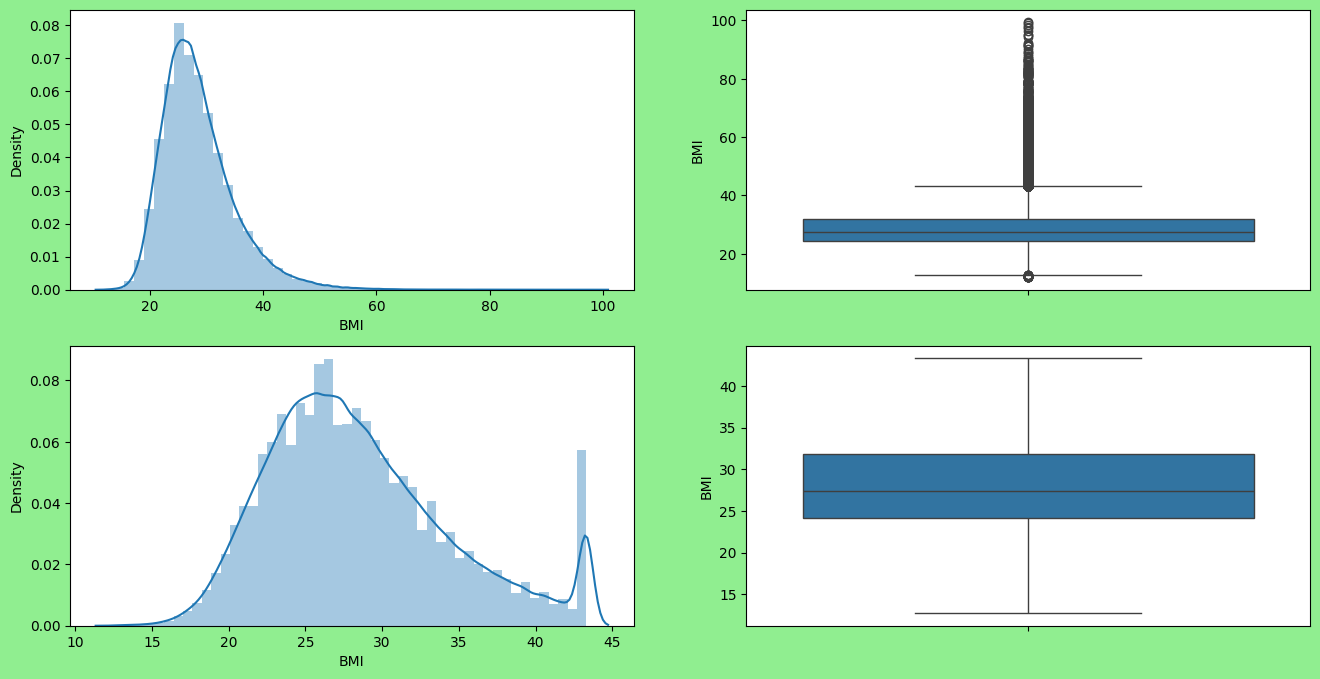

In [64]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['BMI'])

plt.subplot(2,2,2)
sns.boxplot(df['BMI'])

plt.subplot(2,2,3)
sns.distplot(new_df['BMI'])

plt.subplot(2,2,4)
sns.boxplot(new_df['BMI'])

plt.show()

In [65]:
new_df['Alcohol_Consumption']=np.where(new_df['Alcohol_Consumption']>high_out_Alcohol,
                    high_out_Alcohol,
                    np.where(new_df['Alcohol_Consumption']<low_out_Alcohol,
                    low_out_Alcohol,
                    new_df['Alcohol_Consumption']
    )
)

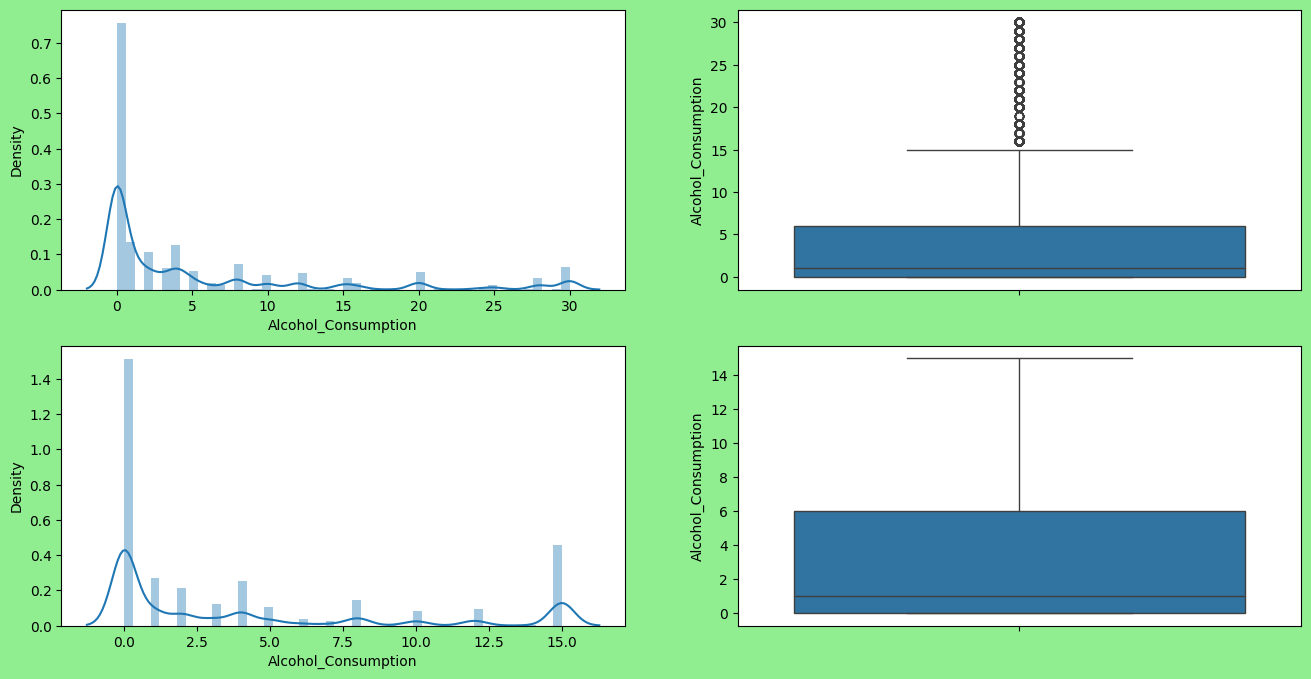

In [66]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['Alcohol_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['Alcohol_Consumption'])

plt.subplot(2,2,3)
sns.distplot(new_df['Alcohol_Consumption'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Alcohol_Consumption'])

plt.show()

In [67]:
new_df['Fruit_Consumption']=np.where(new_df['Fruit_Consumption']>high_out_Fruit,
                    high_out_Fruit,
                    np.where(new_df['Fruit_Consumption']<low_out_Fruit,
                    low_out_Fruit,
                    new_df['Fruit_Consumption']
    )
)

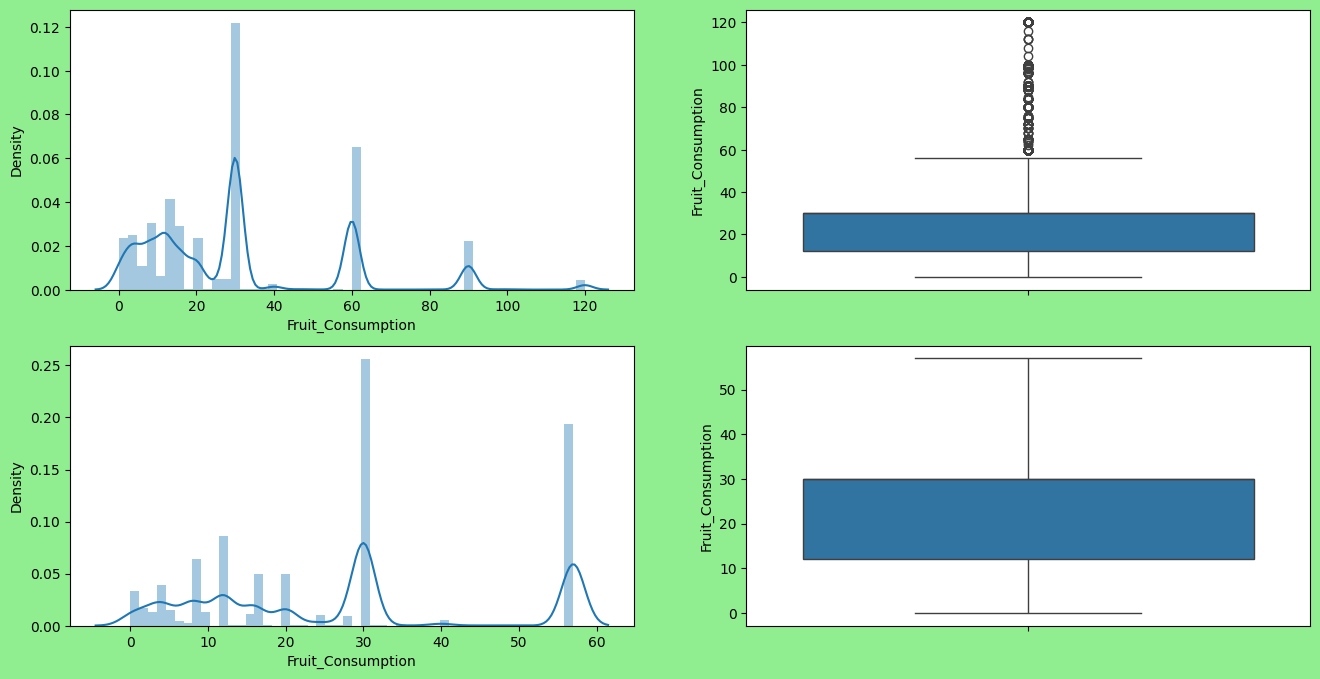

In [68]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['Fruit_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['Fruit_Consumption'])

plt.subplot(2,2,3)
sns.distplot(new_df['Fruit_Consumption'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Fruit_Consumption'])

plt.show()

In [69]:
new_df['Green_Vegetables_Consumption']=np.where(new_df['Green_Vegetables_Consumption']>high_out_Green,
                    high_out_Green,
                    np.where(new_df['Green_Vegetables_Consumption']<low_out_Green,
                    low_out_Green,
                    new_df['Green_Vegetables_Consumption']
    )
)

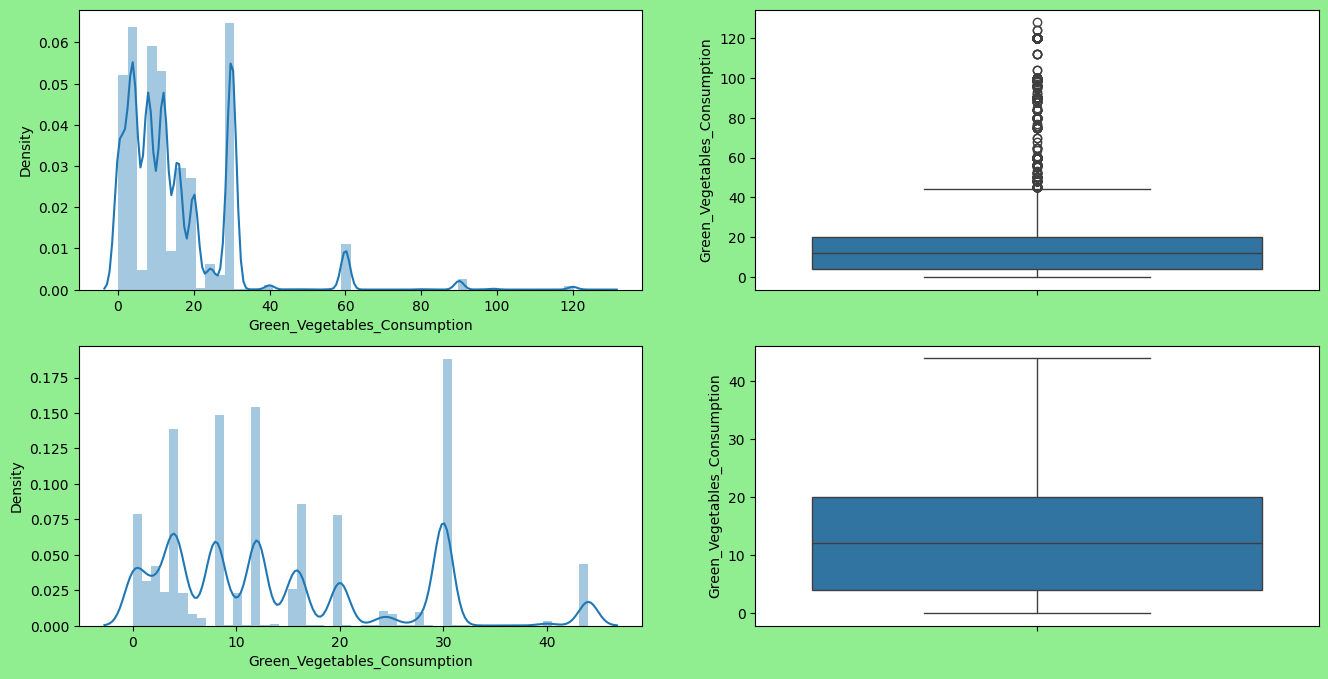

In [70]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['Green_Vegetables_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['Green_Vegetables_Consumption'])

plt.subplot(2,2,3)
sns.distplot(new_df['Green_Vegetables_Consumption'])

plt.subplot(2,2,4)
sns.boxplot(new_df['Green_Vegetables_Consumption'])

plt.show()

In [71]:
new_df['FriedPotato_Consumption']=np.where(new_df['FriedPotato_Consumption']>high_out_Fried,
                    high_out_Fried,
                    np.where(new_df['FriedPotato_Consumption']<low_out_Fried,
                    low_out_Fried,
                    new_df['FriedPotato_Consumption']
    )
)

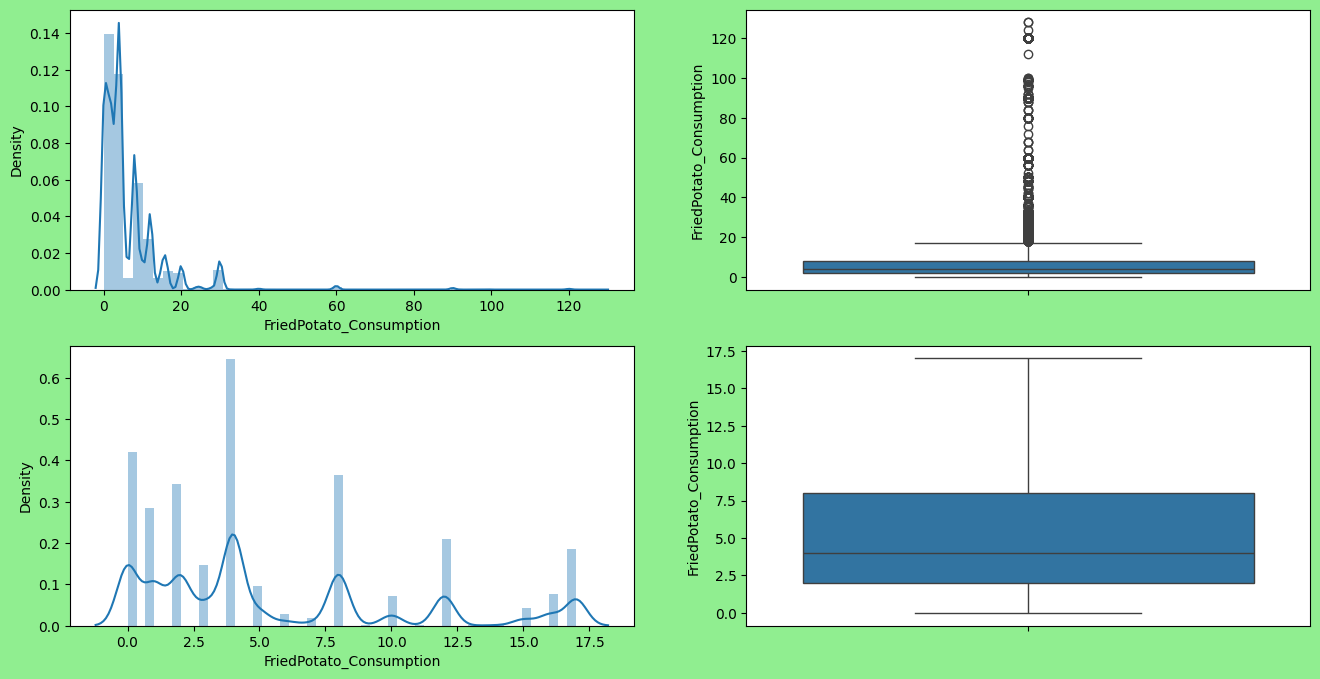

In [72]:
plt.figure(figsize=(16,8),facecolor="lightgreen")
plt.subplot(2,2,1)
sns.distplot(df['FriedPotato_Consumption'])

plt.subplot(2,2,2)
sns.boxplot(df['FriedPotato_Consumption'])

plt.subplot(2,2,3)
sns.distplot(new_df['FriedPotato_Consumption'])

plt.subplot(2,2,4)
sns.boxplot(new_df['FriedPotato_Consumption'])

plt.show()

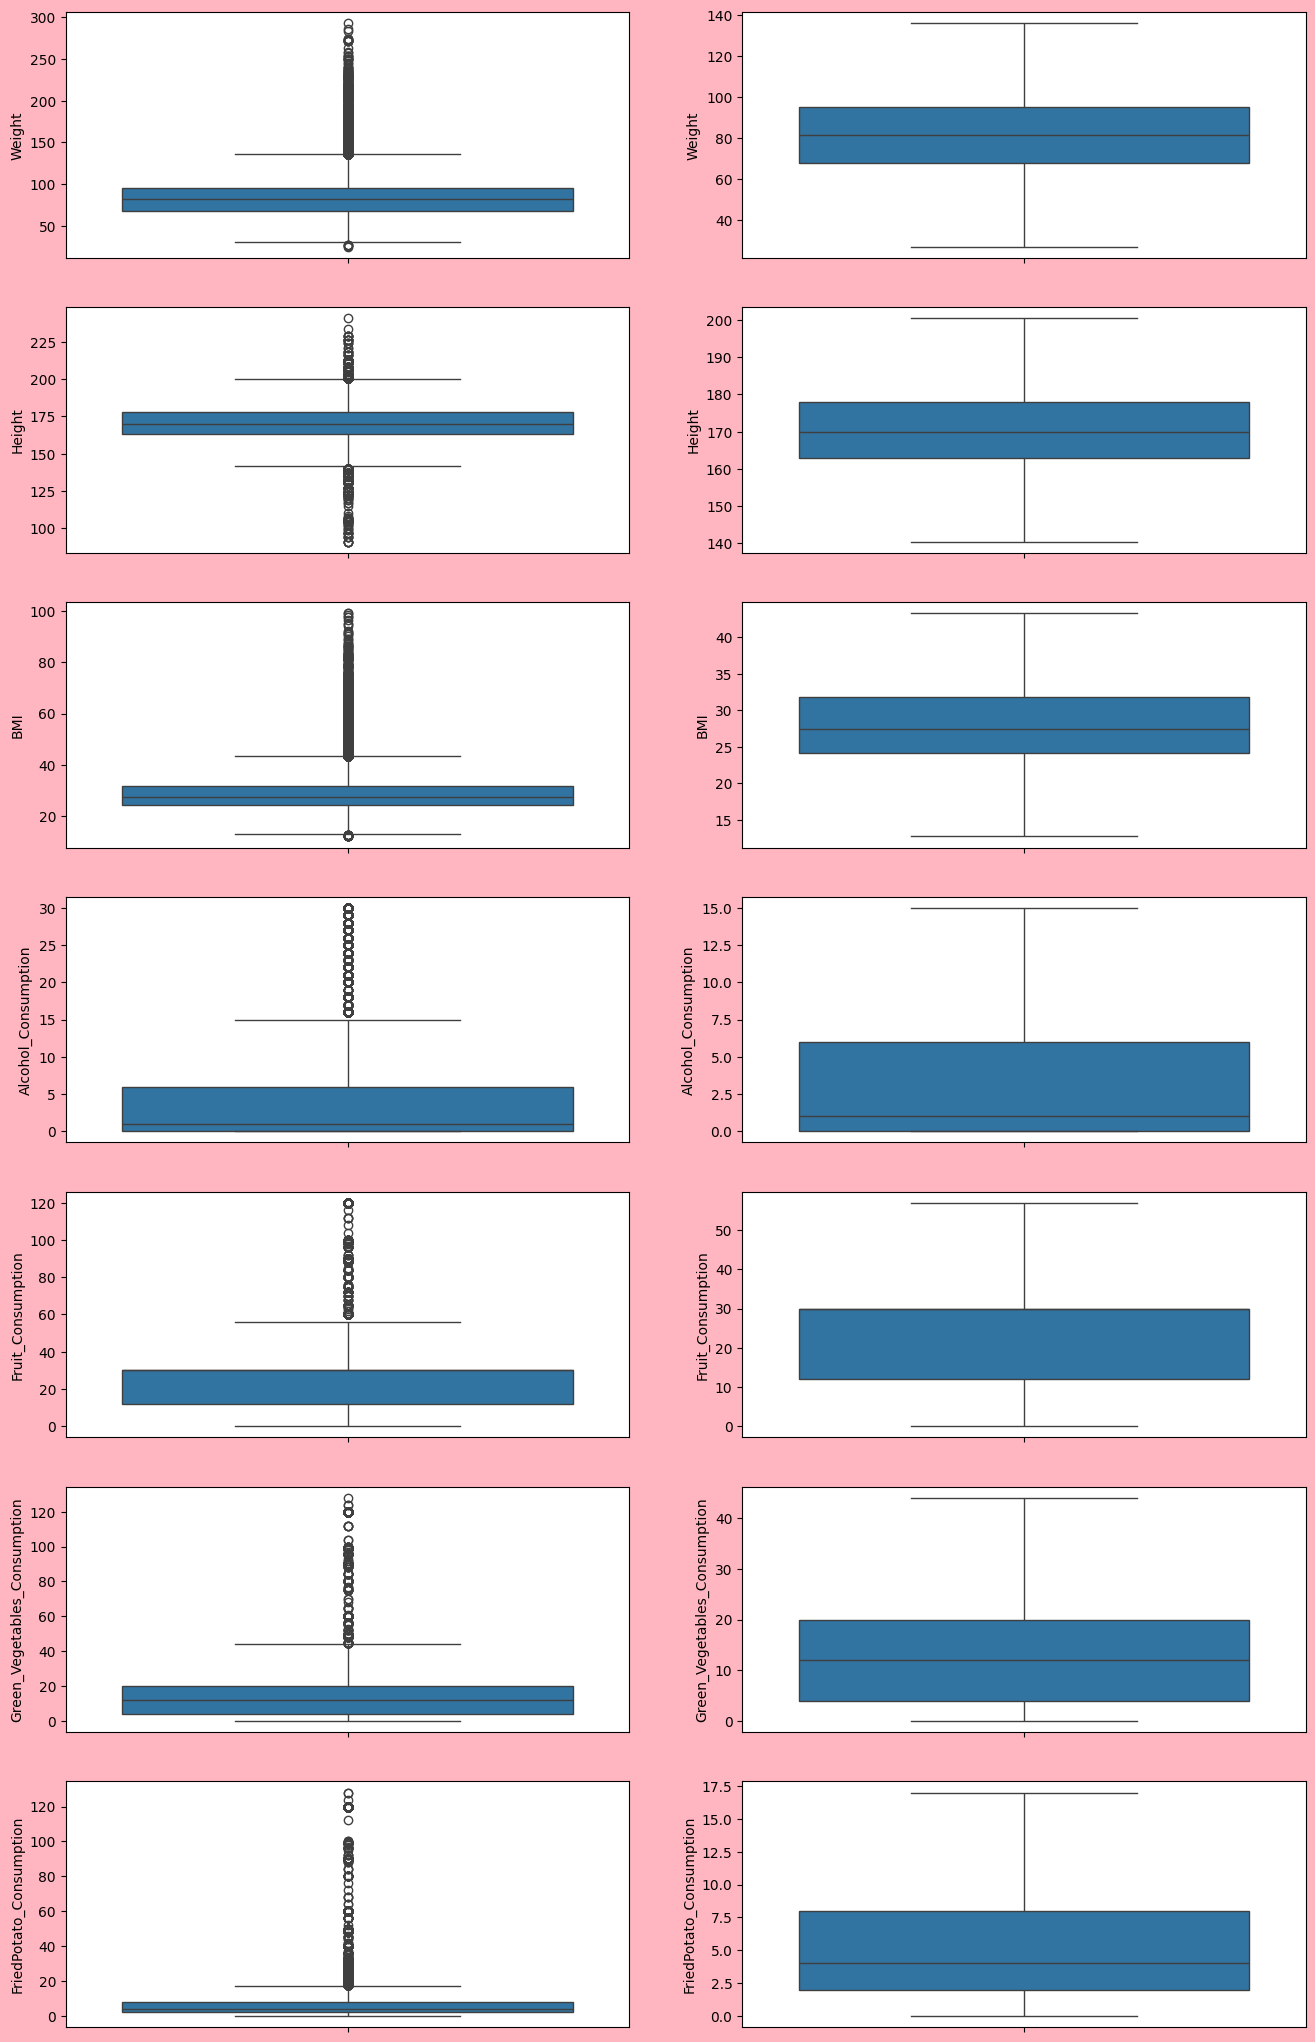

In [73]:
plt.figure(figsize=(16,30),facecolor="lightpink")
plt.subplot(8,2,1)
sns.boxplot(df['Weight'])

plt.subplot(8,2,2)
sns.boxplot(new_df['Weight'])

plt.subplot(8,2,3)
sns.boxplot(df['Height'])

plt.subplot(8,2,4)
sns.boxplot(new_df['Height'])

plt.subplot(8,2,5)
sns.boxplot(df['BMI'])

plt.subplot(8,2,6)
sns.boxplot(new_df['BMI'])

plt.subplot(8,2,7)
sns.boxplot(df['Alcohol_Consumption'])

plt.subplot(8,2,8)
sns.boxplot(new_df['Alcohol_Consumption'])

plt.subplot(8,2,9)
sns.boxplot(df['Fruit_Consumption'])

plt.subplot(8,2,10)
sns.boxplot(new_df['Fruit_Consumption'])

plt.subplot(8,2,11)
sns.boxplot(df['Green_Vegetables_Consumption'])

plt.subplot(8,2,12)
sns.boxplot(new_df['Green_Vegetables_Consumption'])

plt.subplot(8,2,13)
sns.boxplot(df['FriedPotato_Consumption'])

plt.subplot(8,2,14)
sns.boxplot(new_df['FriedPotato_Consumption'])

plt.show()

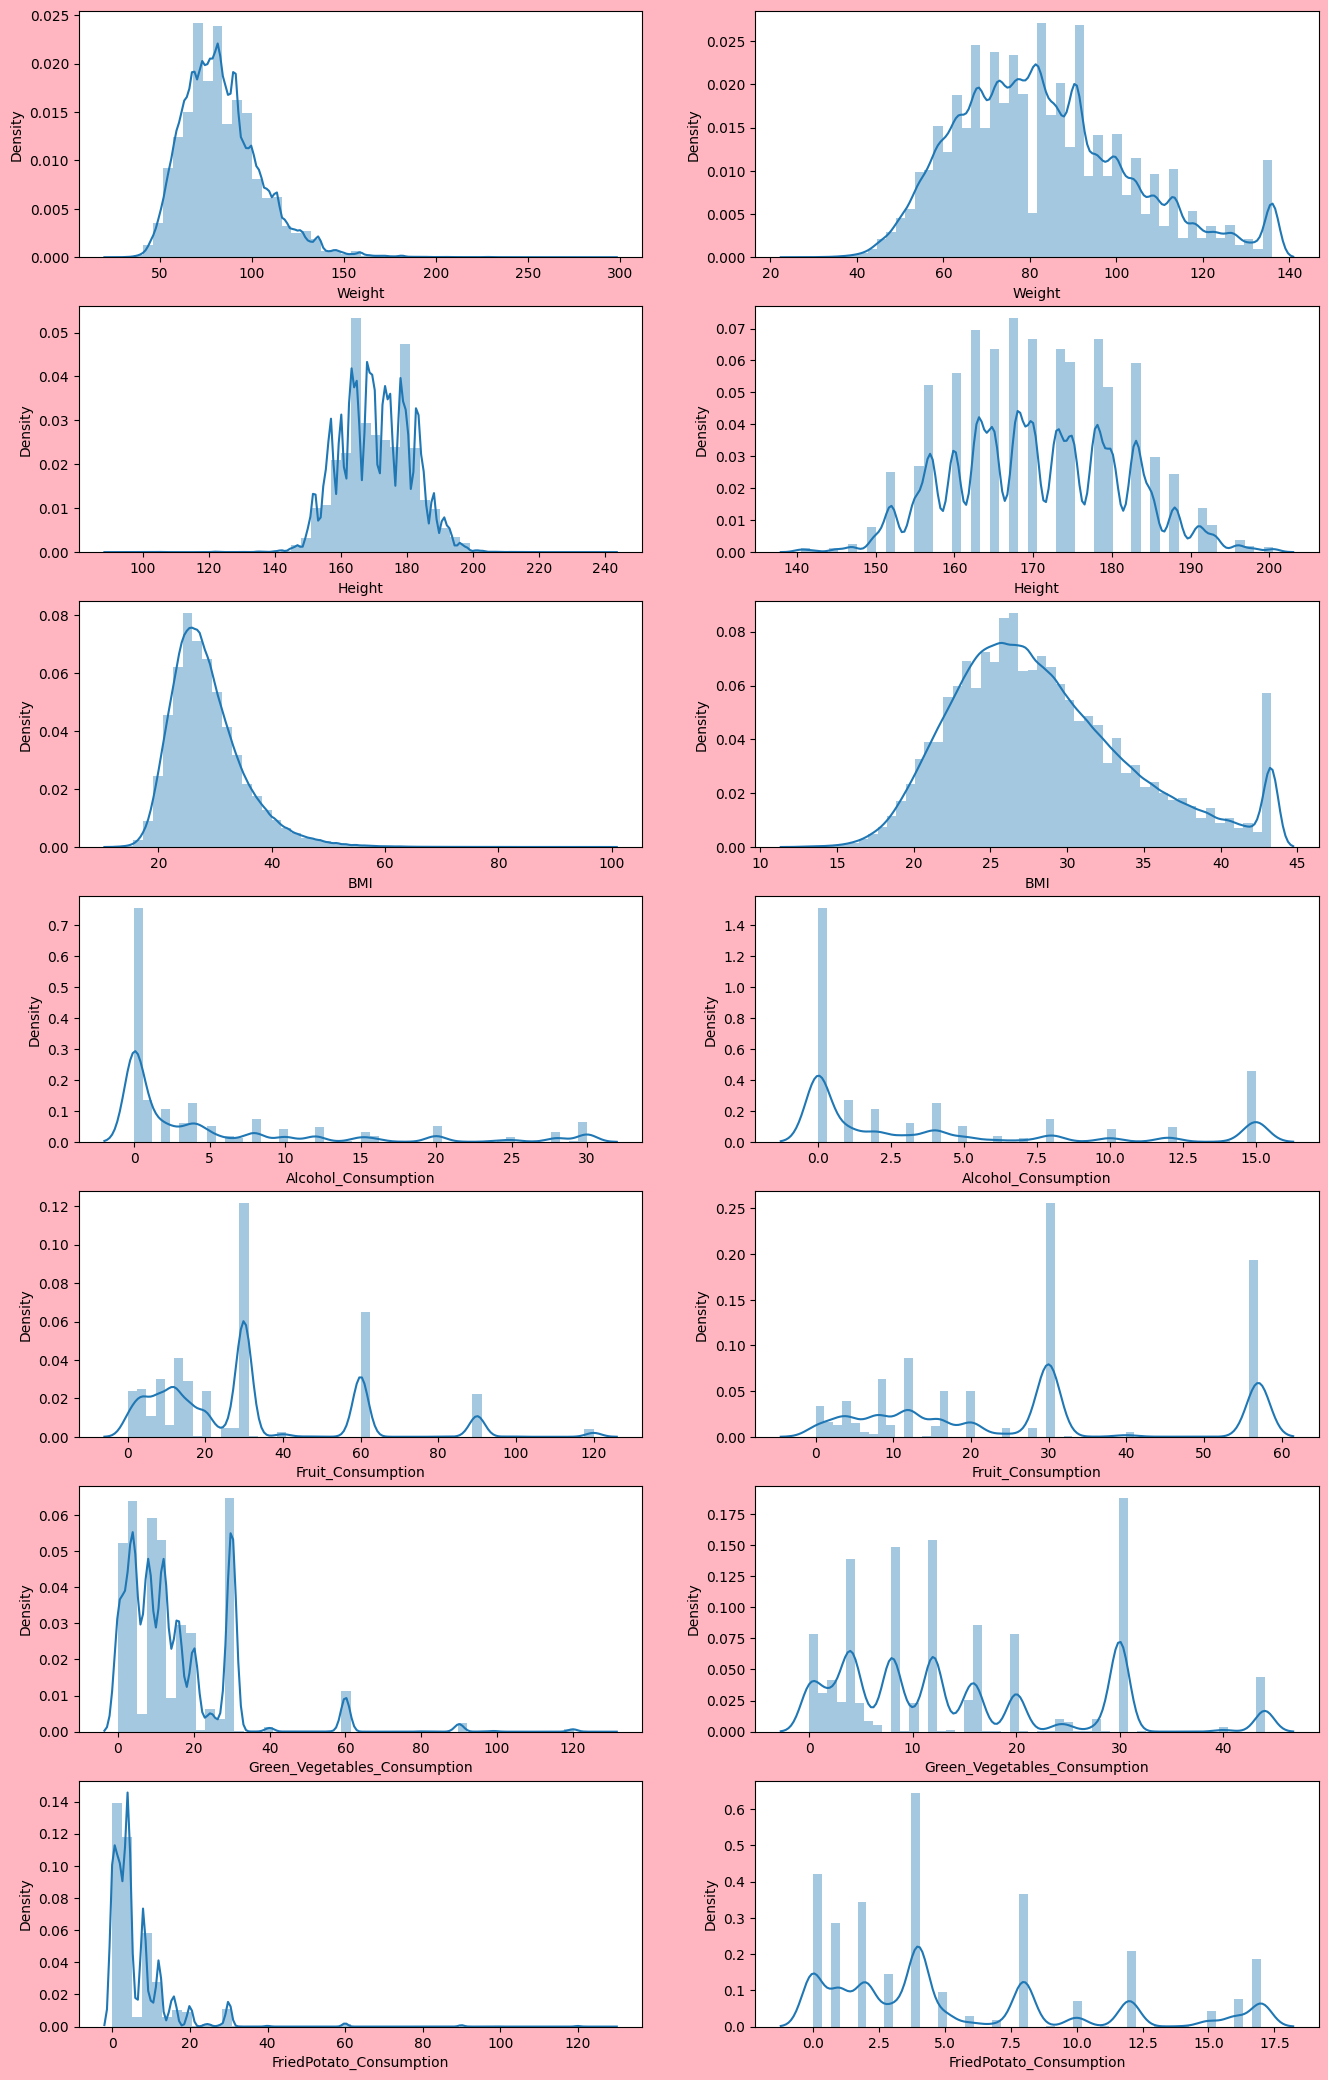

In [74]:
plt.figure(figsize=(16,30),facecolor="lightpink")
plt.subplot(8,2,1)
sns.distplot(df['Weight'])

plt.subplot(8,2,2)
sns.distplot(new_df['Weight'])

plt.subplot(8,2,3)
sns.distplot(df['Height'])

plt.subplot(8,2,4)
sns.distplot(new_df['Height'])

plt.subplot(8,2,5)
sns.distplot(df['BMI'])

plt.subplot(8,2,6)
sns.distplot(new_df['BMI'])

plt.subplot(8,2,7)
sns.distplot(df['Alcohol_Consumption'])

plt.subplot(8,2,8)
sns.distplot(new_df['Alcohol_Consumption'])

plt.subplot(8,2,9)
sns.distplot(df['Fruit_Consumption'])

plt.subplot(8,2,10)
sns.distplot(new_df['Fruit_Consumption'])

plt.subplot(8,2,11)
sns.distplot(df['Green_Vegetables_Consumption'])

plt.subplot(8,2,12)
sns.distplot(new_df['Green_Vegetables_Consumption'])

plt.subplot(8,2,13)
sns.distplot(df['FriedPotato_Consumption'])

plt.subplot(8,2,14)
sns.distplot(new_df['FriedPotato_Consumption'])

plt.show()

In [75]:
for i in new_df.select_dtypes(include='number'):
    skewness=new_df[i].skew()
    print("The skewness of",i,"is",skewness)

The skewness of General_Health is -0.15571858806271865
The skewness of Checkup is -2.1679599334060424
The skewness of Exercise is -1.317226479312391
The skewness of Heart_Disease is 3.0746353750454234
The skewness of Skin_Cancer is 2.7208208779974217
The skewness of Other_Cancer is 2.7280097844221034
The skewness of Depression is 1.4963635501124137
The skewness of Diabetes is 2.0511467540106216
The skewness of Arthritis is 0.7360867223842527
The skewness of Sex is 0.07477388382181174
The skewness of Age_Category is -0.2616081931947562
The skewness of Height is 0.07212210084698939
The skewness of Weight is 0.5930280717004383
The skewness of BMI is 0.6612778837830368
The skewness of Smoking_History is 0.38425362845448024
The skewness of Alcohol_Consumption is 1.1783276897389163
The skewness of Fruit_Consumption is 0.46648060507886313
The skewness of Green_Vegetables_Consumption is 0.8303843403378427
The skewness of FriedPotato_Consumption is 0.99809576647361


# Feature Scaling

In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
scaler=StandardScaler()

In [78]:
new_df.columns

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height', 'Weight', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

In [79]:
new_df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height,Weight,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,3,2,0,0,0,0,0,0,1,0,10,150.0,32.66,14.54,1,0.0,30.0,16.0,12.0
1,4,4,0,1,0,0,0,2,0,0,10,165.0,77.11,28.29,0,0.0,30.0,0.0,4.0
2,4,4,1,0,0,0,0,2,0,0,8,163.0,88.45,33.47,0,4.0,12.0,3.0,16.0
3,3,4,1,1,0,0,0,2,0,1,11,180.0,93.44,28.73,0,0.0,30.0,30.0,8.0
4,2,4,0,0,0,0,0,0,0,1,12,191.0,88.45,24.37,1,0.0,8.0,4.0,0.0


In [80]:
y =new_df['Heart_Disease']
y

0         0
1         1
2         0
3         1
4         0
         ..
308849    0
308850    0
308851    0
308852    0
308853    0
Name: Heart_Disease, Length: 308774, dtype: int64

In [81]:
x = new_df.drop('Heart_Disease',axis = 1)

In [82]:
scaled = scaler.fit_transform(x)

In [83]:
Df=pd.DataFrame(scaled)

In [84]:
Df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.486453,-1.485784,-1.85601,-0.327997,-0.3273,-0.500730,-0.425469,1.433619,-0.963312,0.983087,-1.952236,-2.513347,-2.350805,1.210415,-0.736159,0.164794,0.160540,1.299110
1,1.155791,0.475679,-1.85601,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,-0.963312,0.983087,-0.532416,-0.304614,-0.026787,-0.826163,-0.736159,0.164794,-1.232358,-0.286419
2,1.155791,0.475679,0.53879,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,-0.963312,0.415468,-0.721725,0.258874,0.848734,-0.826163,0.010926,-0.796957,-0.971190,2.091875
3,0.486453,0.475679,0.53879,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,1.038085,1.266897,0.887404,0.506829,0.047582,-0.826163,-0.736159,0.164794,1.379326,0.506346
4,-0.182885,0.475679,-1.85601,-0.327997,-0.3273,-0.500730,-0.425469,-0.697536,1.038085,1.550706,1.928606,0.258874,-0.689343,1.210415,-0.736159,-1.010680,-0.884134,-1.079183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,1.155791,0.475679,0.53879,-0.327997,-0.3273,-0.500730,-0.425469,-0.697536,1.038085,-1.571200,-0.248452,-0.079020,0.101668,-0.826163,0.010926,0.164794,-0.535909,-1.079183
308770,-0.852223,-0.505053,0.53879,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,1.038085,0.699277,0.887404,-0.665365,-1.177810,-0.826163,0.758011,-0.636665,2.598111,-0.286419
308771,1.155791,-3.447247,0.53879,-0.327997,-0.3273,1.997086,3.715589,-0.697536,-0.963312,-1.287390,-1.289654,-1.093696,-0.635257,1.210415,0.010926,0.699101,-0.535909,-0.286419
308772,1.155791,0.475679,0.53879,-0.327997,-0.3273,-0.500730,-0.425469,-0.697536,1.038085,0.699277,1.171368,-0.191817,-0.797516,-0.826163,-0.175845,0.164794,-0.187685,-1.079183


# VIF

In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=pd.DataFrame()
vif['VIF']=[variance_inflation_factor(scaled,i)for i in range(scaled.shape[1])]
vif['Features']=x.columns
print(vif)

          VIF                      Features
0    1.007851                General_Health
1    1.083286                       Checkup
2    1.115336                      Exercise
3    1.098235                   Skin_Cancer
4    1.073572                  Other_Cancer
5    1.095468                    Depression
6    1.118669                      Diabetes
7    1.240164                     Arthritis
8    2.074067                           Sex
9    1.469893                  Age_Category
10  17.565975                        Height
11  62.565075                        Weight
12  47.788811                           BMI
13   1.073437               Smoking_History
14   1.076119           Alcohol_Consumption
15   1.142514             Fruit_Consumption
16   1.132363  Green_Vegetables_Consumption
17   1.094414       FriedPotato_Consumption


In [86]:
x=df.drop('Heart_Disease',axis=1)

In [87]:
x=x.drop('Weight',axis=1)

In [88]:
x_scaler=scaler.fit_transform(x)

In [89]:
x_scaler = pd.DataFrame(scaler.transform(x), columns=x.columns)
x_scaler

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,0.486453,-1.485784,-1.85601,-0.327997,-0.3273,-0.500730,-0.425469,1.433619,-0.963312,0.983087,-1.934170,-2.159627,1.210415,-0.621621,0.006661,0.059656,0.664362
1,1.155791,0.475679,-1.85601,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,-0.963312,0.983087,-0.526833,-0.051636,-0.826163,-0.621621,0.006661,-1.012235,-0.267624
2,1.155791,0.475679,0.53879,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,-0.963312,0.415468,-0.714478,0.742501,-0.826163,-0.133842,-0.716876,-0.811255,1.130355
3,0.486453,0.475679,0.53879,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,1.038085,1.266897,0.880503,0.015819,-0.826163,-0.621621,0.006661,0.997561,0.198369
4,-0.182885,0.475679,-1.85601,-0.327997,-0.3273,-0.500730,-0.425469,-0.697536,1.038085,1.550706,1.912549,-0.652605,1.210415,-0.621621,-0.877663,-0.744262,-0.733617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,1.155791,0.475679,0.53879,-0.327997,-0.3273,-0.500730,-0.425469,-0.697536,1.038085,-1.571200,-0.245366,0.064878,-0.826163,-0.133842,0.006661,-0.476289,-0.733617
308770,-0.852223,-0.505053,0.53879,-0.327997,-0.3273,-0.500730,2.335236,-0.697536,1.038085,0.699277,0.880503,-1.095666,-0.826163,0.353938,-0.596287,3.007357,-0.267624
308771,1.155791,-3.447247,0.53879,-0.327997,-0.3273,1.997086,3.715589,-0.697536,-0.963312,-1.287390,-1.277413,-0.603547,1.210415,-0.133842,0.408626,-0.476289,-0.267624
308772,1.155791,0.475679,0.53879,-0.327997,-0.3273,-0.500730,-0.425469,-0.697536,1.038085,0.699277,1.161970,-0.750723,-0.826163,-0.255786,0.006661,-0.208317,-0.733617


In [90]:
vif=pd.DataFrame()
vif['VIF']=[variance_inflation_factor(x_scaler,i)for i in range(x_scaler.shape[1])]
vif['Features']=x.columns
print(vif)

         VIF                      Features
0   1.006912                General_Health
1   1.082830                       Checkup
2   1.105218                      Exercise
3   1.098178                   Skin_Cancer
4   1.073470                  Other_Cancer
5   1.095310                    Depression
6   1.116039                      Diabetes
7   1.239503                     Arthritis
8   2.039615                           Sex
9   1.451183                  Age_Category
10  1.994251                        Height
11  1.108470                           BMI
12  1.073562               Smoking_History
13  1.064593           Alcohol_Consumption
14  1.114332             Fruit_Consumption
15  1.103070  Green_Vegetables_Consumption
16  1.046948       FriedPotato_Consumption


In [91]:
x_scaler.corr()

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
General_Health,1.000000,0.027431,0.036864,0.020864,0.004456,0.002313,-0.025157,0.014013,-0.013733,0.032378,0.001634,0.013967,0.004324,0.023673,-0.010957,-0.021517,-0.000682
Checkup,0.027431,1.000000,-0.029803,0.079313,0.086779,0.035674,0.127858,0.150225,-0.100058,0.223116,-0.088951,0.060903,-0.010064,-0.046631,0.039297,0.034925,-0.055706
Exercise,0.036864,-0.029803,1.000000,-0.003963,-0.054363,-0.084673,-0.136589,-0.124785,0.059355,-0.122334,0.091622,-0.155732,-0.093241,0.095028,0.136782,0.124983,-0.036904
Skin_Cancer,0.020864,0.079313,-0.003963,1.000000,0.150781,-0.013041,0.032947,0.136146,0.009658,0.272075,0.006799,-0.037647,0.032793,0.042734,0.024143,0.012894,-0.038945
Other_Cancer,0.004456,0.086779,-0.054363,0.150781,1.000000,0.015861,0.063873,0.129320,-0.042061,0.234464,-0.043476,0.001015,0.053390,-0.008704,0.007992,-0.003215,-0.033326
Depression,0.002313,0.035674,-0.084673,-0.013041,0.015861,1.000000,0.053115,0.121562,-0.141457,-0.103195,-0.091315,0.109557,0.100215,-0.028200,-0.039938,-0.051134,0.018108
Diabetes,-0.025157,0.127858,-0.136589,0.032947,0.063873,0.053115,1.000000,0.133839,-0.013135,0.192806,-0.043093,0.205292,0.053720,-0.114255,-0.019085,-0.027333,-0.004281
Arthritis,0.014013,0.150225,-0.124785,0.136146,0.129320,0.121562,0.133839,1.000000,-0.100047,0.370996,-0.097794,0.137924,0.123128,-0.024968,-0.001983,-0.018803,-0.050994
Sex,-0.013733,-0.100058,0.059355,0.009658,-0.042061,-0.141457,-0.013135,-0.100047,1.000000,-0.060234,0.698129,0.010978,0.073407,0.129311,-0.092486,-0.069169,0.130049
Age_Category,0.032378,0.223116,-0.122334,0.272075,0.234464,-0.103195,0.192806,0.370996,-0.060234,1.000000,-0.120922,-0.007426,0.133155,0.012833,0.043661,0.036030,-0.142761


# Train-Test Split

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=21)

In [94]:
x_train.head()

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
121465,2,4,1,0,0,0,0,0,0,3,155,21.16,0,0,30,4,4
141148,1,4,1,0,1,0,1,0,1,7,183,38.92,0,0,15,25,5
119696,4,4,0,0,0,0,0,0,0,12,163,21.63,0,6,30,20,12
170551,0,4,0,0,0,0,0,0,1,10,178,24.11,1,0,20,20,16
108852,1,3,1,0,0,1,0,0,1,0,178,23.96,1,2,12,8,8


In [95]:
x_test.head()

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height,BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
110577,3,4,0,0,0,0,2,0,1,8,168,31.96,0,0,3,0,1
130213,2,4,0,0,1,0,0,1,0,7,175,28.06,0,4,90,30,4
18719,4,4,1,0,0,0,0,0,0,9,168,32.93,0,2,2,2,16
194360,4,4,1,0,0,0,0,0,1,6,175,25.84,0,0,8,5,14
143935,4,4,1,0,0,0,0,0,0,7,168,25.82,1,0,30,30,8


In [96]:
x_train.shape

(247019, 17)

# Logistic Regression

In [97]:
from sklearn.linear_model import LogisticRegression

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [99]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [100]:
y_pred = model.predict(x_test)

In [101]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [102]:
Acc=accuracy_score(y_test, y_pred)

In [103]:
Acc

0.9173346287749979

In [104]:
x_pred = model.predict(x_train)

In [105]:
accuracy_score(y_train, x_pred)

0.9183261206627831

In [106]:
confusion_matrix(y_test, y_pred)

array([[56479,   237],
       [ 4868,   171]])

In [107]:
confusion_matrix(y_train, x_pred)

array([[226202,    885],
       [ 19290,    642]])

In [108]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.92      1.00      0.96     56716\n           1       0.42      0.03      0.06      5039\n\n    accuracy                           0.92     61755\n   macro avg       0.67      0.51      0.51     61755\nweighted avg       0.88      0.92      0.88     61755\n'

In [109]:
classification_report(y_train, x_pred)

'              precision    recall  f1-score   support\n\n           0       0.92      1.00      0.96    227087\n           1       0.42      0.03      0.06     19932\n\n    accuracy                           0.92    247019\n   macro avg       0.67      0.51      0.51    247019\nweighted avg       0.88      0.92      0.88    247019\n'

# KNN

In [110]:
from sklearn.neighbors import KNeighborsClassifier

In [111]:
knn = KNeighborsClassifier()

In [112]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [113]:
y_pred = knn.predict(x_test)

In [114]:
x_pred = knn.predict(x_train)

In [115]:
accuracy_score(y_test, y_pred)

0.9108736134725933

In [116]:
accuracy_score(y_train, x_pred)

0.9244835417518491

In [117]:
confusion_matrix(y_test, y_pred)

array([[56063,   653],
       [ 4851,   188]])

In [118]:
confusion_matrix(y_train, x_pred)

array([[225850,   1237],
       [ 17417,   2515]])

In [119]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.92      0.99      0.95     56716\n           1       0.22      0.04      0.06      5039\n\n    accuracy                           0.91     61755\n   macro avg       0.57      0.51      0.51     61755\nweighted avg       0.86      0.91      0.88     61755\n'

In [120]:
classification_report(y_train, x_pred)

'              precision    recall  f1-score   support\n\n           0       0.93      0.99      0.96    227087\n           1       0.67      0.13      0.21     19932\n\n    accuracy                           0.92    247019\n   macro avg       0.80      0.56      0.59    247019\nweighted avg       0.91      0.92      0.90    247019\n'

# Decision Tree

In [121]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [122]:
Dt = DecisionTreeClassifier()

In [123]:
Dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [124]:
y_pred = Dt.predict(x_test)

In [125]:
x_pred = Dt.predict(x_train)

In [126]:
accuracy_score(y_test, y_pred)

0.86326613229698

In [127]:
accuracy_score(y_train, x_pred)

0.9999919034568191

In [128]:
confusion_matrix(y_test, y_pred)

array([[52080,  4636],
       [ 3808,  1231]])

In [129]:
confusion_matrix(y_train, x_pred)

array([[227087,      0],
       [     2,  19930]])

In [130]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.93      0.92      0.93     56716\n           1       0.21      0.24      0.23      5039\n\n    accuracy                           0.86     61755\n   macro avg       0.57      0.58      0.58     61755\nweighted avg       0.87      0.86      0.87     61755\n'

In [131]:
classification_report(y_train, x_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00    227087\n           1       1.00      1.00      1.00     19932\n\n    accuracy                           1.00    247019\n   macro avg       1.00      1.00      1.00    247019\nweighted avg       1.00      1.00      1.00    247019\n'

# Tree Pruning

In [132]:
model = DecisionTreeClassifier(max_depth=5)

In [133]:
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [134]:
train_accuracy = model.score(x_train, y_train)
train_accuracy

0.919637760658087

In [135]:
test_accuracy = model.score(x_test, y_test)
test_accuracy

0.918872965751761

In [136]:
y_pred = model.predict(x_test)

In [137]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[56593   123]
 [ 4887   152]]


In [138]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56716
           1       0.55      0.03      0.06      5039

    accuracy                           0.92     61755
   macro avg       0.74      0.51      0.51     61755
weighted avg       0.89      0.92      0.88     61755



# Joblib to save our model

In [139]:
import joblib

In [140]:
joblib.dump(knn, 'KNeighborsClassifier.joblib')

['KNeighborsClassifier.joblib']